In [ ]:
pip install qiskit qiskit-aer pylatexenc

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.quantum_info import Statevector

## Objective 1: Measurement Result Visualizations

Qiskit provides comprehensive visualization tools for analyzing quantum measurement results and quantum states.

Basic Histogram Plotting

`plot_histogram` is the most common visualization for quantum measurement results, showing the frequency distribution of measurement outcomes.

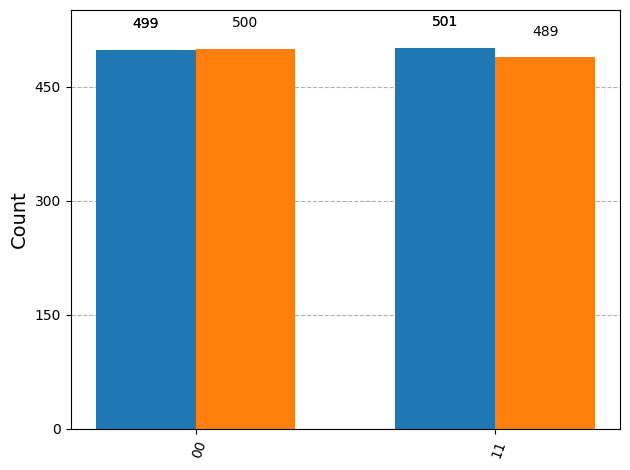

In [ ]:
from qiskit.visualization import plot_histogram

counts1 = {'00':499, '11': 501}
counts2 = {'00': 500, '11': 489}

data = [counts1, counts2]
plot_histogram(data)

Customized Histogram Visualization

Common customization parameters for histograms:
- `title`: Chart title
- `figsize`: Figure dimensions (width, height) in inches
- `legend`: Labels for different data series
- `color`: Custom colors for each data series
- `filename(str)`: file path to save image

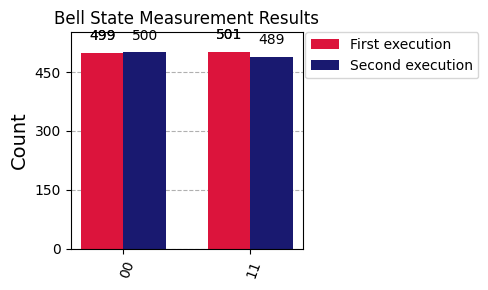

In [ ]:
legend = ['First execution', 'Second execution']
title = 'Bell State Measurement Results'
figsize = (5, 3)
color = ['crimson', 'midnightblue']

plot_histogram(data, legend=legend, title=title, figsize=figsize, color=color)

### Types of Quantum Visualizations

#### Basic Counts Visualization

- `plot_histogram`: Bar chart of measurement outcome frequencies

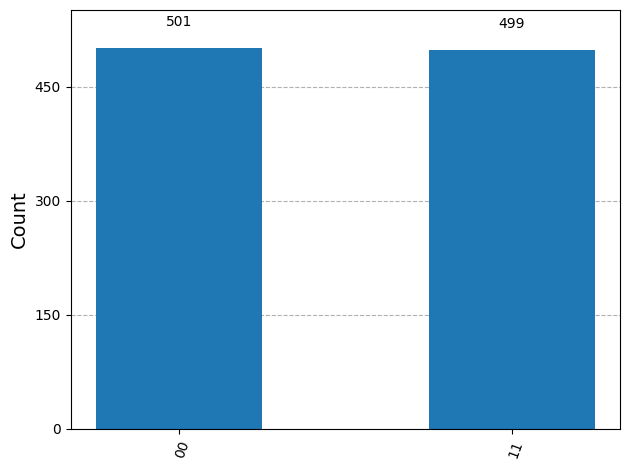

In [ ]:
counts = {'00':501, "11": 499}
plot_histogram(counts)

- `plot_distribution`: Probability distribution visualization

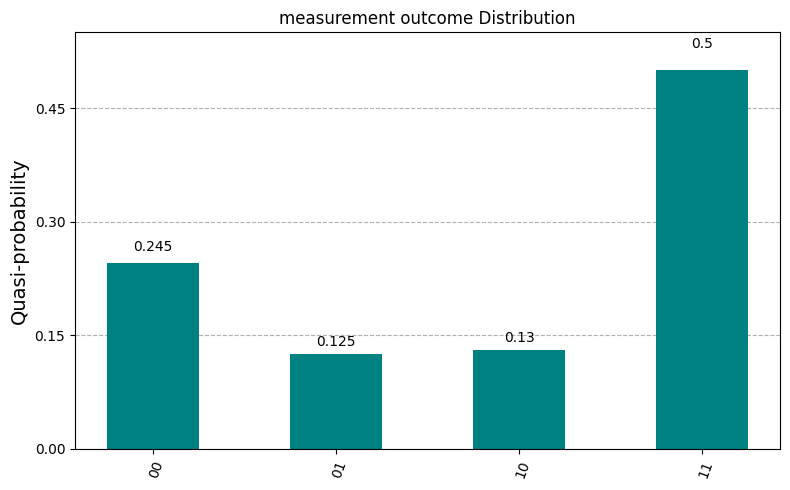

In [ ]:
from qiskit.visualization import plot_distribution

counts_data = {
    '00': 245,
    '01':125,
    '10':130,
    '11':500
}

plot_distribution(counts_data,
                  title='measurement outcome Distribution',
                  figsize=(8, 5),
                  color='teal',
                  sort='asc')

Multiple Distributions can be plotted also.

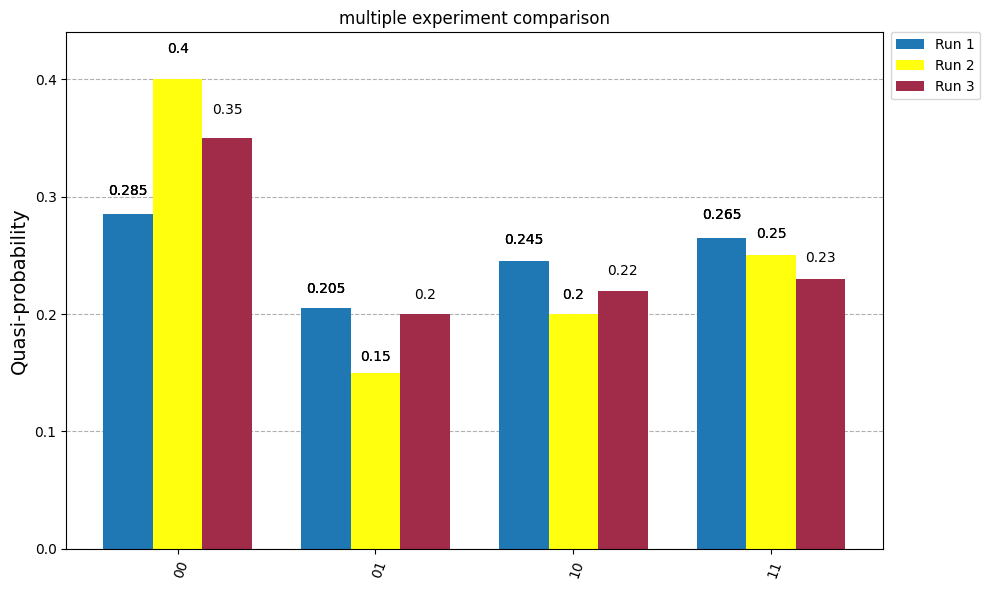

In [ ]:
counts_comparison = [
    {'00': 285, '01': 205, '10':245, '11':265},
    {'00': 400, '01': 150, '10':200, '11':250},
    {'00': 350, '01':200, '10':220, '11':230}
]

plot_distribution(counts_comparison,
                  title='multiple experiment comparison',
                  legend=['Run 1', 'Run 2', 'Run 3'],
                  figsize=(10,6),
                  color=['#1f77b4', '#ffff0e', "#a02c49"],
                  bar_labels=True)

Quantum States Visualization

- `plot_bloch_vector`: Single qubit state on Bloch sphere

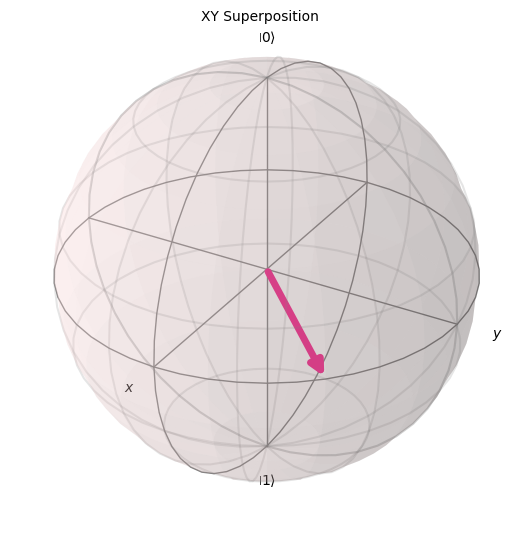

In [ ]:
from qiskit.visualization import plot_bloch_vector

bloch_vectors = [1/np.sqrt(2), 1/np.sqrt(2), 0]
title = "XY Superposition"

plot_bloch_vector(bloch_vectors,
                  title=title,
                  coord_type='cartesian')

- `plot_bloch_multivector`: Multiple qubits on separate Bloch spheres

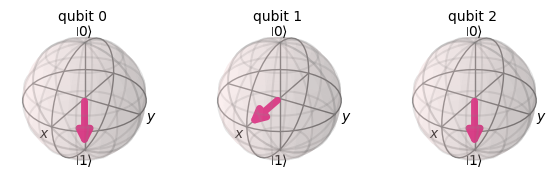

In [ ]:
from qiskit.visualization import plot_bloch_multivector

qc = QuantumCircuit(3)
qc.x(0)
qc.h(1)
qc.y(2)
state = Statevector(qc)

plot_bloch_multivector(state, figsize=[2,2])

- `plot_state_city`: 3D cityscape plot of statevector amplitudes

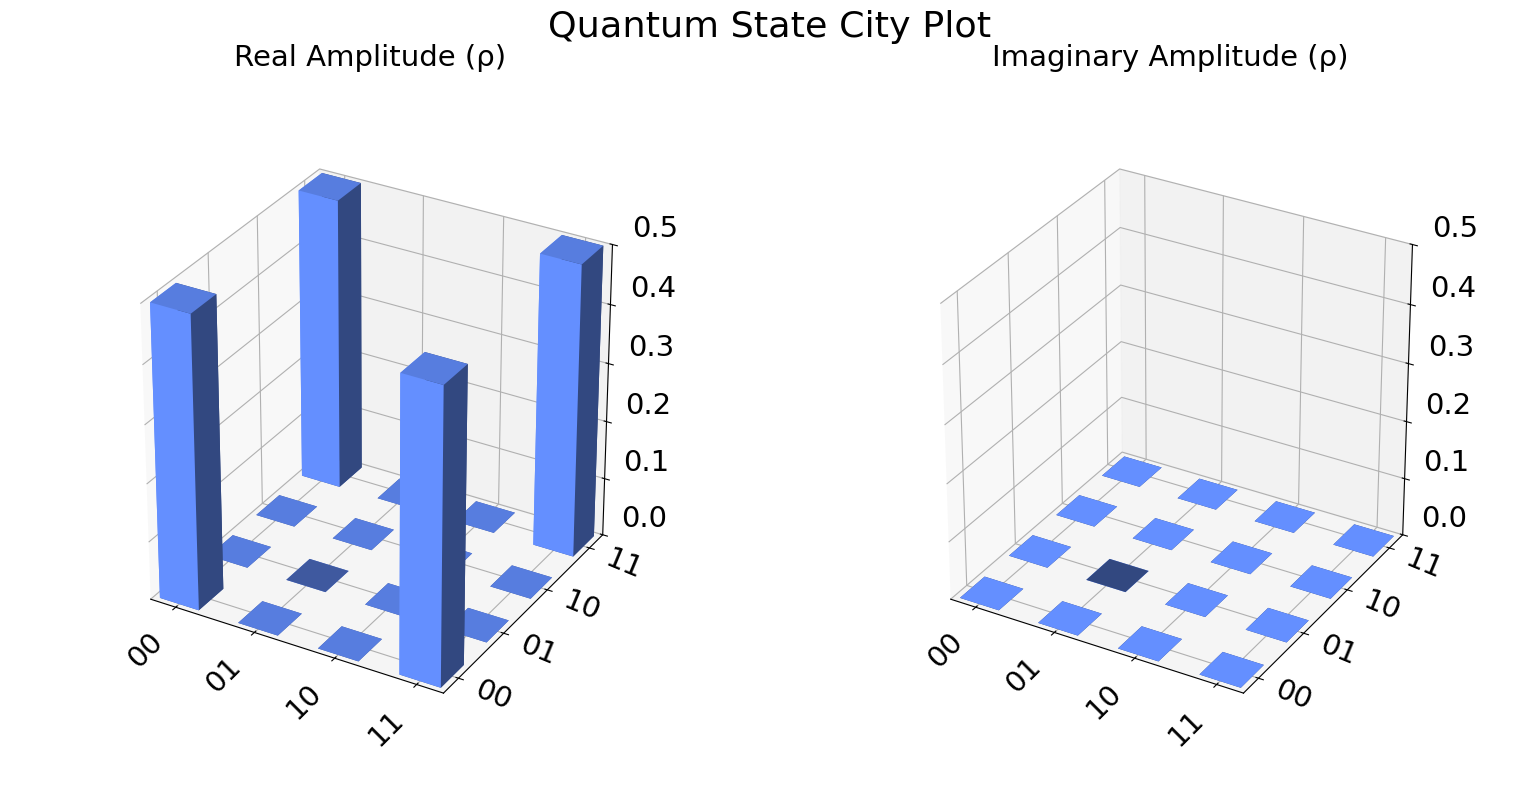

In [ ]:
from qiskit.visualization import plot_state_city

qc_bell = QuantumCircuit(2)
qc_bell.h(0)
qc_bell.cx(0,1)
state_bell = Statevector(qc_bell)

plot_state_city(state_bell, title='Quantum State City Plot')

# City plots show the magnitude of statevector or density matrix elements

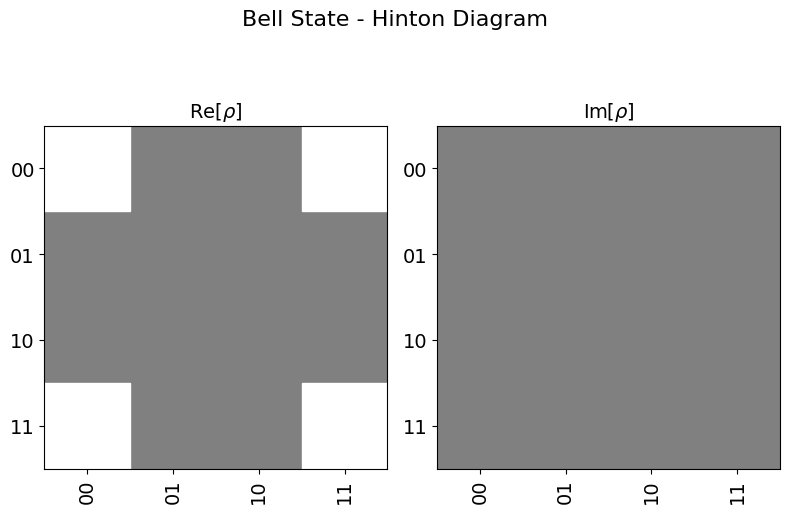

In [ ]:
from qiskit.visualization import plot_state_hinton

plot_state_hinton(state_bell,
                  title="Bell State - Hinton Diagram",
                  figs)

- `plot_state_paulivec`: Pauli expectation values visualization


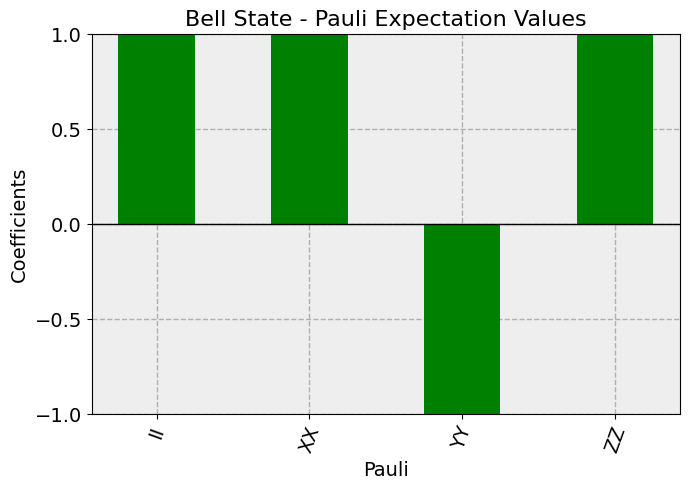

In [ ]:
from qiskit.visualization import plot_state_paulivec

plot_state_paulivec(state_bell,
                    title="Bell State - Pauli Expectation Values",
                    figsize=(7, 5),
                    color='green')

- `plot_state_qsphere`: Q-sphere representation of quantum states

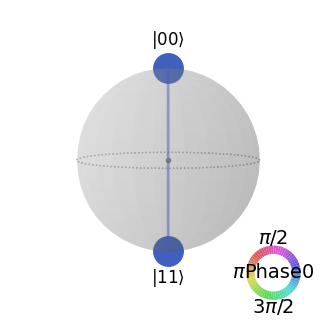

In [ ]:
from qiskit.visualization import plot_state_qsphere

plot_state_qsphere(state_bell, figsize=(4, 4))

OTHER VISUALIZATION CATEGORIES

**Device Visualizations:**

- `plot_gate_map`: Physical qubit connectivity and layout


- `plot_error_map`: Quantum error rates across device

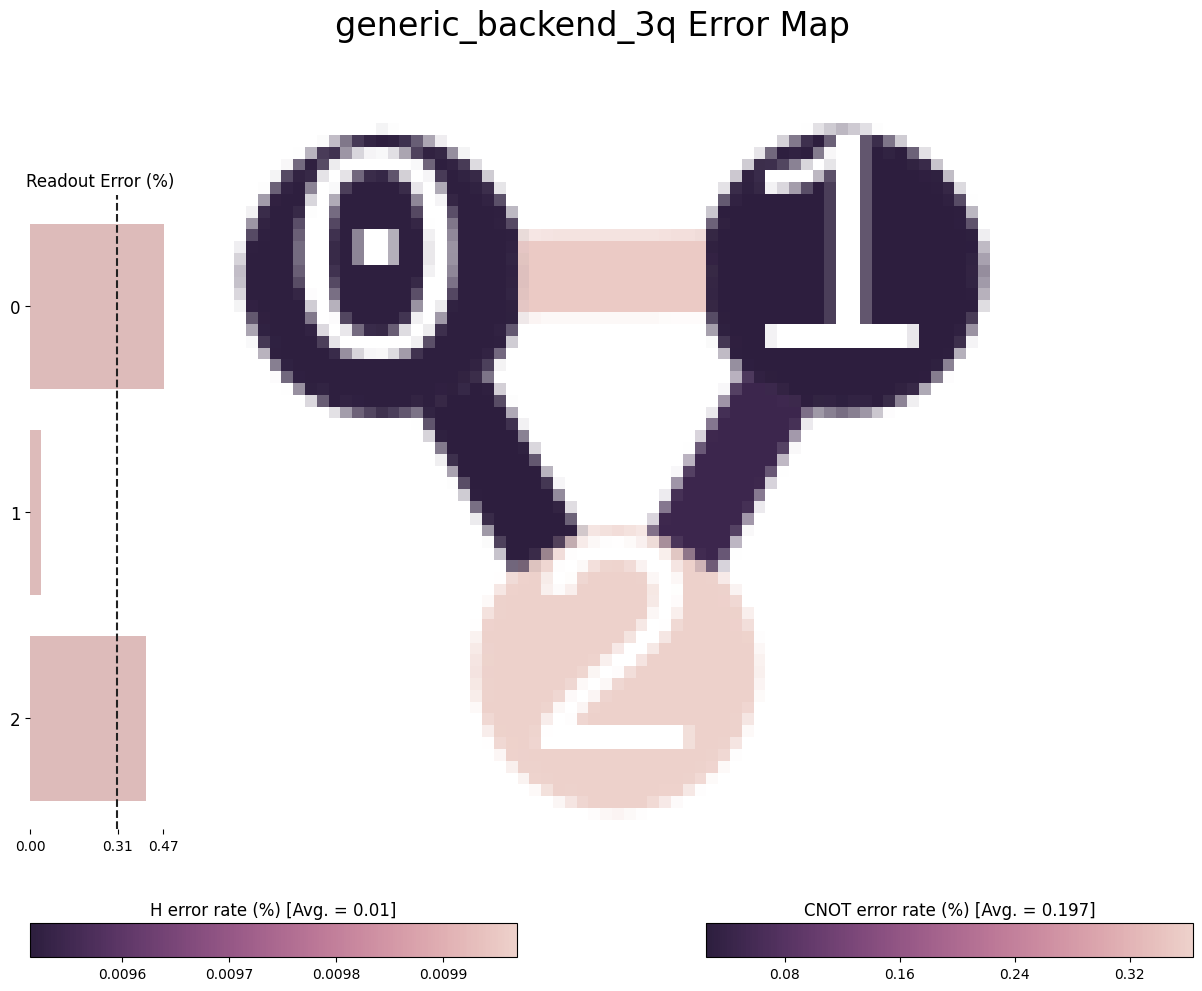

In [ ]:
from qiskit.visualization import plot_error_map

backend = GenericBackendV2(num_qubits=3)
plot_error_map(backend)


- `plot_circuit_layout`: How circuits map to physical hardware

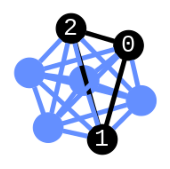

In [ ]:
from qiskit.visualization import plot_circuit_layout

qcGHZ = QuantumCircuit(3,3)
qcGHZ.h(0)
qcGHZ.cx(0,1)
qcGHZ.cx(0,2)
qcGHZ.measure_all()

backend = GenericBackendV2(num_qubits=7)
qcGHZoptimized = transpile(qcGHZ, backend=backend, optimization_level=3)
plot_circuit_layout(qcGHZoptimized, backend)

- `plot_coupling_map`: Qubit connectivity graph

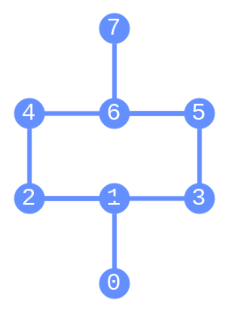

In [ ]:
from qiskit.visualization import plot_coupling_map

num_qubits = 8
qubit_coordinates = [[0, 1], [1, 1], [1, 0], [1, 2], [2, 0], [2, 2], [2, 1], [3, 1]]
coupling_map = [[0, 1], [1, 2], [2, 3], [3, 5], [4, 5], [5, 6], [2, 4], [6, 7]]

plot_coupling_map(num_qubits, qubit_coordinates, coupling_map)

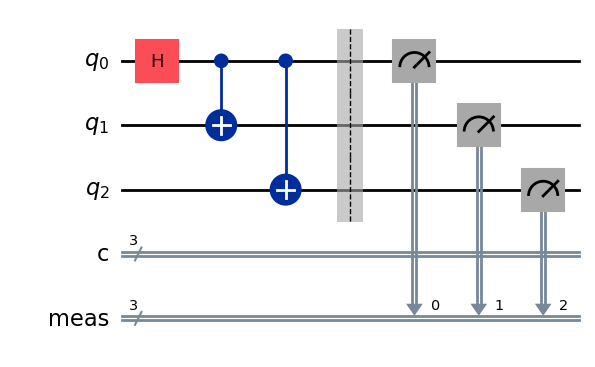

In [ ]:
from qiskit.visualization import circuit_drawer
circuit_drawer(qcGHZ, output='mpl')

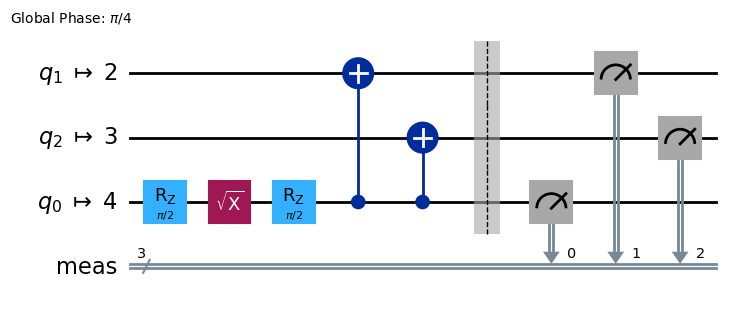

In [ ]:
circuit_drawer(qcGHZoptimized, output='mpl')


**DAG Visualizations:**
- `dag_drawer`: Directed Acyclic Graph representation

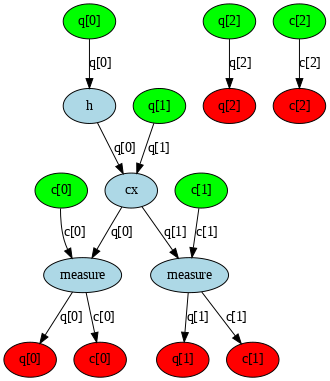

In [ ]:
from qiskit.converters import circuit_to_dag
from qiskit.visualization import dag_drawer

qc = QuantumCircuit(3,3)
qc.h(0)
qc.cx(0,1)
qc.measure(0,0)
qc.measure(1,1)

dag = circuit_to_dag(qc)

dag_drawer(dag)


**Pass Manager Visualizations:**
- `pass_manager_drawer`: Compilation pass sequences

**Timeline Visualizations:**
- `timeline_drawer`: Quantum operation scheduling

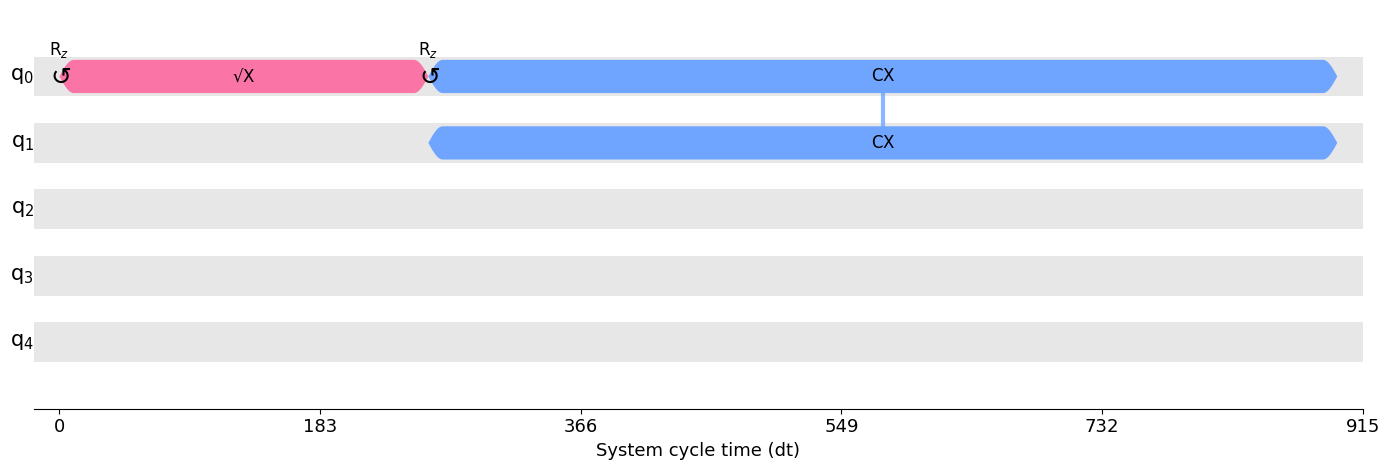

In [ ]:
from qiskit.visualization.timeline import draw

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

backend = GenericBackendV2(5)

qc = transpile(qc, backend, layout_method='trivial')
draw(qc, target=backend.target)


**Single Qubit State Transitions:**
- `visualize_transition`: Animated Bloch sphere transitions

**Array/Matrix Visualizations:**
- `array_to_latex`: Convert arrays to LaTeX format

## Objective 3: Gate Map Visualization

Gate map visualization shows the physical layout and connectivity of quantum processors

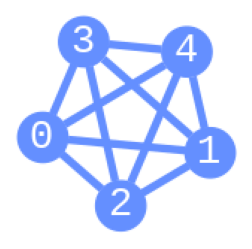

In [ ]:
from qiskit.visualization import plot_gate_map

backend = GenericBackendV2(num_qubits=5)

plot_gate_map(backend, figsize=[3, 3])

##**Visualize Quantum States**


Visualizing quantum states can be done using Bloch multivector plots and Q-sphere representations in Qiskit. These visualizations provide intuitive ways to understand multi-qubit quantum states and their properties.


In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix
import numpy as np



Bloch Multivector Visualization

The `plot_bloch_multivector` function displays multiple Bloch spheres, one for each qubit in a multi-qubit system. Each sphere shows the expectation values of the Pauli operators (X, Y, Z) for that specific qubit.

It is most effective for examining the state of individual qubits within multi-qubit systems. However, it can not show entanglement or phase relationships between qubits. and Its primary use case is analyzing how quantum gates influence each qubit in a circuit.

Statevector: Statevector([ 0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j],
            dims=(2, 2))


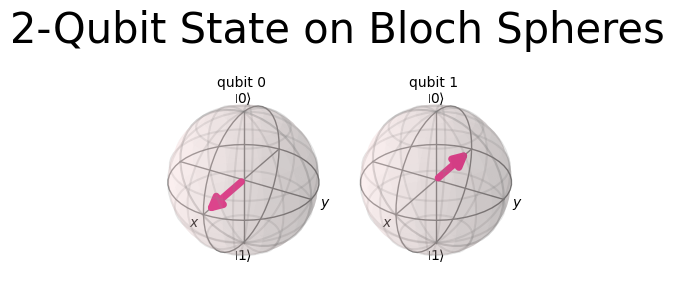

In [ ]:
from qiskit.visualization import plot_bloch_multivector

qc = QuantumCircuit(2)
qc.h(0)
qc.x(1)
qc.h(1)


state = Statevector(qc)
print("Statevector:", state)
plot_bloch_multivector(state, title='2-Qubit State on Bloch Spheres', figsize=(2,2), title_font_size=30)

BLOCH MULTIVECTOR WITH DENSITY MATRIX AND REVERSED QUBIT ORDER

density matrices can represent mixed states (statistical ensembles) and `reverse_bits` changes the display order of qubits

8


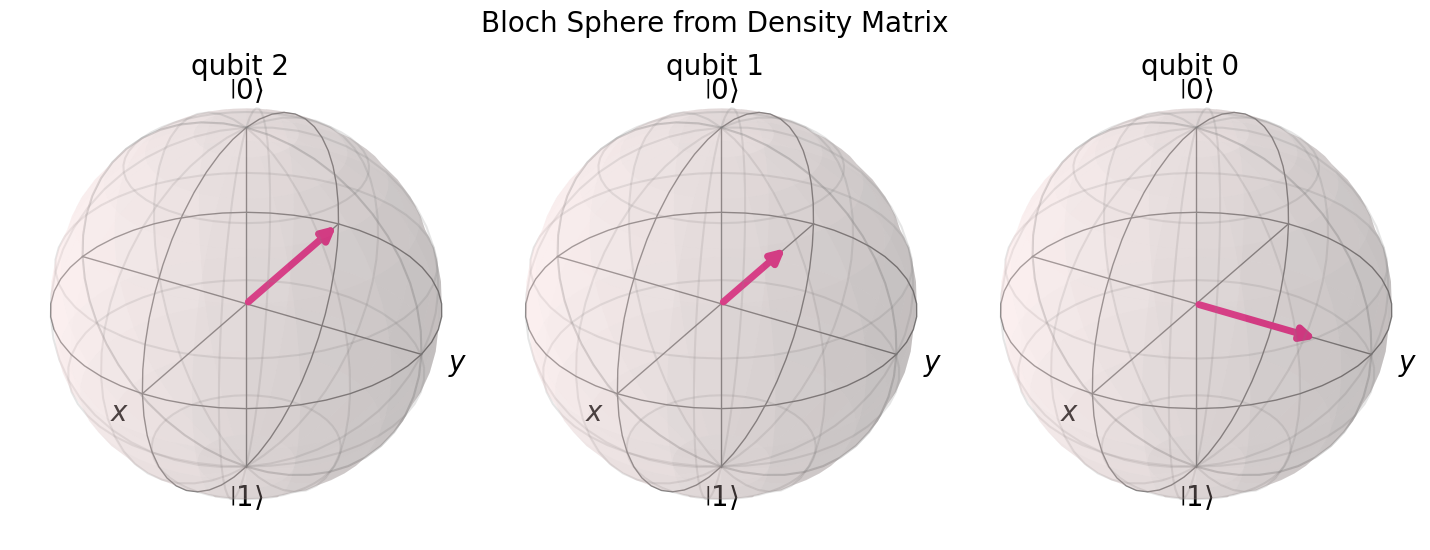

In [ ]:
# complex 3-qubit circuit

qc = QuantumCircuit(3)

qc.h([0,1,2])
qc.t(1)
qc.s(0)
qc.z(2)
qc.cx(0,1)
qc.cx(1,2)

# Use DensityMatrix instead of Statevector
# Density matrices can represent both pure and mixed states

matrix = DensityMatrix(qc)
print(matrix.dim)

plot_bloch_multivector(matrix, title='Bloch Sphere from Density Matrix',
                       reverse_bits=True,
                       font_size=20)

##Q-SPhere Visualization

The Q-sphere provides a compact way to visualize multi-qubit states by mapping computational basis states to points on a sphere, with colors and arrows representing phases and amplitudes.

It is most effective for examining the complete multi-qubit quantum state. and it can show entanglement and phase relationships between qubits. However, visualization becomes complex as the nubmer of qubits increase.

Statevector([ 0.        +0.j, -0.70710678+0.j,  0.70710678+0.j,
              0.        +0.j],
            dims=(2, 2))


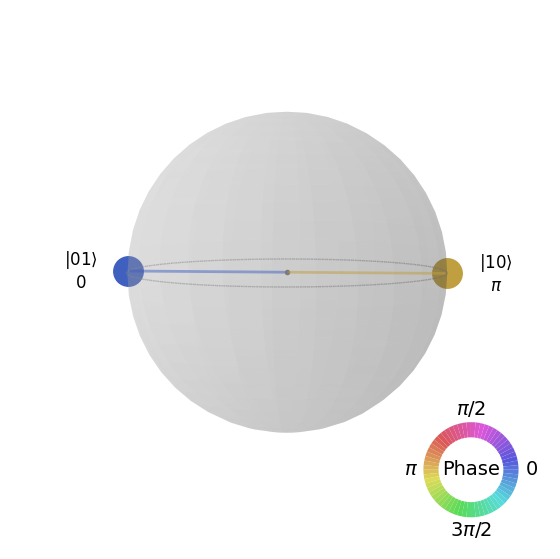

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere

qc = QuantumCircuit(2)
qc.h(0)
qc.z(0)
qc.x(1)
qc.cx(0,1)

state = Statevector(qc)
print(state)
# Visualize on Q-sphere with enhanced options
plot_state_qsphere(state,
                   use_degrees=False,       # Show phases in radians
                   show_state_phases=True,  # Display phase arrows
                   show_state_labels=True)


# - Points on sphere represent computational basis states |00⟩, |01⟩, |10⟩, |11⟩
# - Points size shows magnitude of each amplitude
# - Colors indicate different phase regions

### Advanced Q-Sphere with Density Matrix and Rotation Gates

This example shows a more complex state with custom rotations and demonstrates Q-sphere visualization with density matrices.

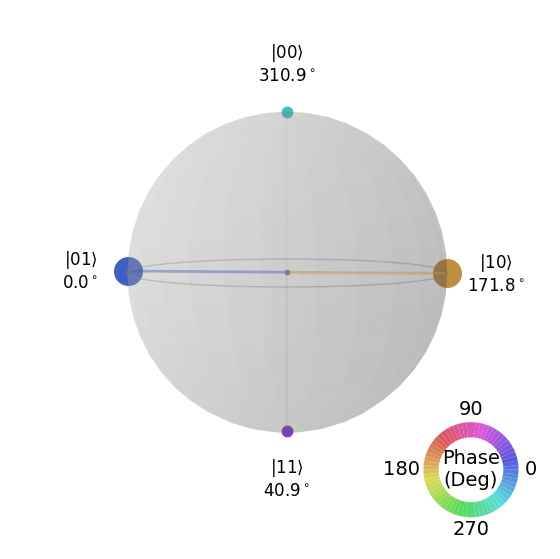

In [ ]:
from qiskit.visualization import plot_state_qsphere

# - Multiple basis states have non-zero amplitudes
# - Phase colors show complex phases introduced by rotation gates
# - Degrees make phase values more intuitive (0° = +1, 180° = -1, etc.)


qc = QuantumCircuit(2)
qc.h([0,1])    # Hadamard on both: creates equal superposition
qc.cz(0,1)     # Controlled-Z: entangles qubits with phase kick
qc.ry(np.pi/3, 0)    # Rotation around Y-axis by 60° on qubit 0
qc.rx(np.pi/6, 1)    # Rotation around X-axis by 30° on qubit 1
qc.z(1)              # Z gate on qubit 1: global phase shift


matrix = DensityMatrix(qc)


plot_state_qsphere(matrix,
                   show_state_phases=True,    # Show phase arrows for each basis state
                   use_degrees=True,          # Display phases in degrees (0-360°)
                   show_state_labels=True)